In [2]:
from pathlib import Path
import multiprocessing as mp

import pandas as pd

In [3]:
from results.repetition import RepetitionResults
from results.results import Results

## Configuration


### Path Configuration


In [ ]:
RES_PARENT_FOLDER = Path("../../results").resolve()
RES_PARENT_FOLDER.mkdir(exist_ok=True)
BATCH_RES = RES_PARENT_FOLDER / "batch_20260204_17-30-33"
BATCH_RES = RES_PARENT_FOLDER / "batch_20260206_21-45-57"


if not BATCH_RES.exists():
    raise FileNotFoundError(f"Results folder not found: {BATCH_RES}")

In [5]:
results = Results.from_folder(BATCH_RES)

Reading topology results from folder: linear_20N
Reading topology results from folder: ring_20N
Reading topology results from folder: random_20N
Reading topology results from folder: star_20N
Reading topology results from folder: grid_20N


In [6]:
PROCESSED_RES_FOLDER = RES_PARENT_FOLDER / "processed_results"
PROCESSED_RES_FOLDER.mkdir(exist_ok=True)
PROCESSED_RES_BATCH = PROCESSED_RES_FOLDER / BATCH_RES.name
PROCESSED_RES_BATCH.mkdir(exist_ok=True)
PROCESSED_RES_FOLDER

PosixPath('/home/simone/uni/spe/SPE-project/results/processed_results')

In [7]:
COMPUTE_HOP_STRETCH = False

In [ ]:
if COMPUTE_HOP_STRETCH:

    HS_FOLDER = PROCESSED_RES_BATCH / "hop_stretch"
    HS_FOLDER.mkdir(exist_ok=True)

    def compute_repetition(repetition: RepetitionResults) -> pd.DataFrame:
        try:
            repetition.compute_hop_stretch()
            repetition.hop_stretch_df["id"] = repetition.id
            return repetition.hop_stretch_df
        except ValueError as e:
            if repetition.neighbor_df is None or repetition.positions_df is None:
                return pd.DataFrame(
                    {
                        "id": [repetition.id],
                    }
                )
            else:
                raise e

    worker_count = mp.cpu_count()

    ctx = mp.get_context("fork")

    for topology in results.topologies:
        print(f"Topology: {topology.topology_type}")

        HS_TOPOLOGY_FOLDER = HS_FOLDER / topology.topology_type
        HS_TOPOLOGY_FOLDER.mkdir(exist_ok=True)

        for channel in topology.channels:

            print(f"  Channel: {channel.channel_type}")

            HS_CHANNEL_FOLDER = HS_TOPOLOGY_FOLDER / channel.channel_type
            HS_CHANNEL_FOLDER.mkdir(exist_ok=True)

            with ctx.Pool(worker_count) as pool:
                try:
                    hs = pool.map(
                        compute_repetition,
                        channel.repetitions,
                        chunksize=max(
                            1, len(channel.repetitions) // (mp.cpu_count() * 4)
                        ),
                    )
                except Exception as e:
                    print(
                        f"Error computing hop stretch for [{topology.topology_type}/{channel.channel_type}]: {e}"
                    )
                    pool.terminate()
                    pool.join()

            hs_df = pd.concat(hs, ignore_index=True)
            hs_df.to_csv(HS_CHANNEL_FOLDER / "hop_stretch.csv", index=False)

## Visualize the Varios Topologies


In [ ]:
from metrics.hop_stretch import (
    build_connectivity_graph,
    build_tree_topology,
    get_positions_nx,
)

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [10]:
np.random.seed(40)

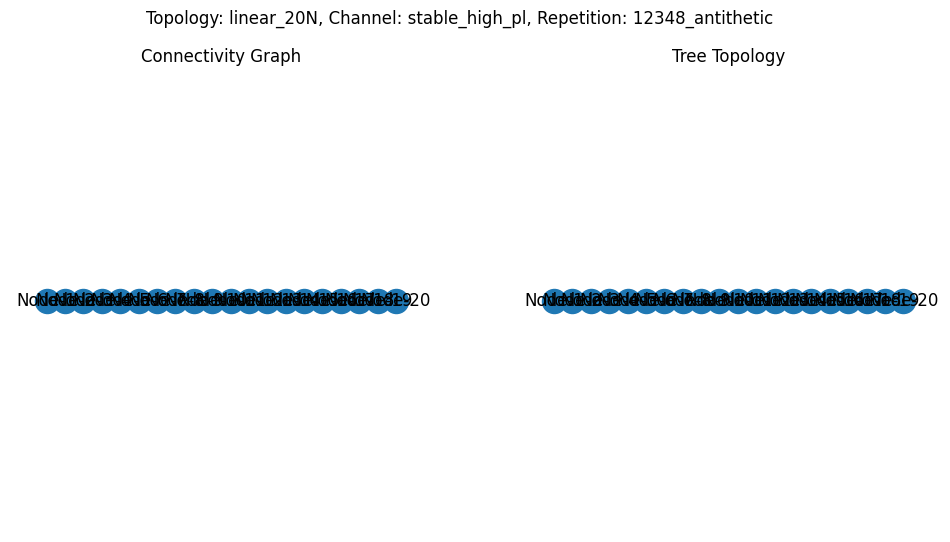

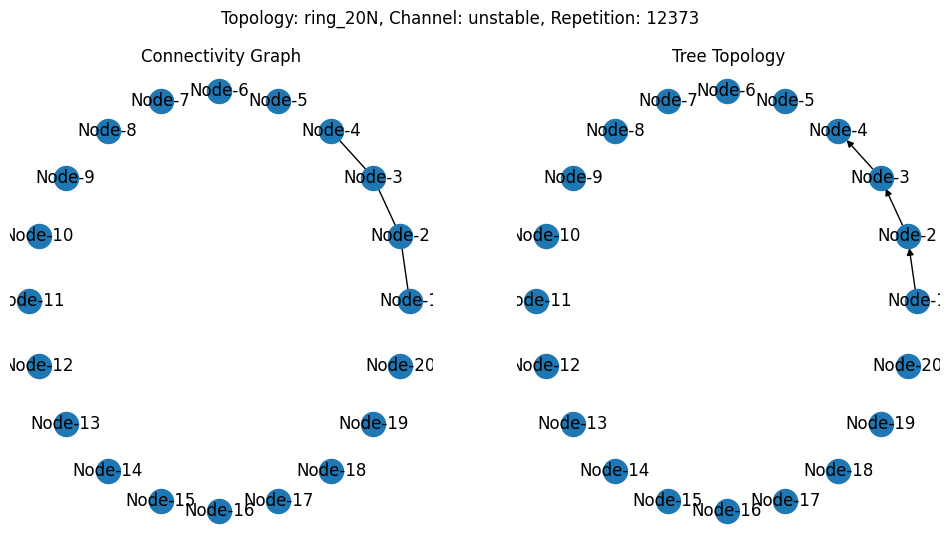

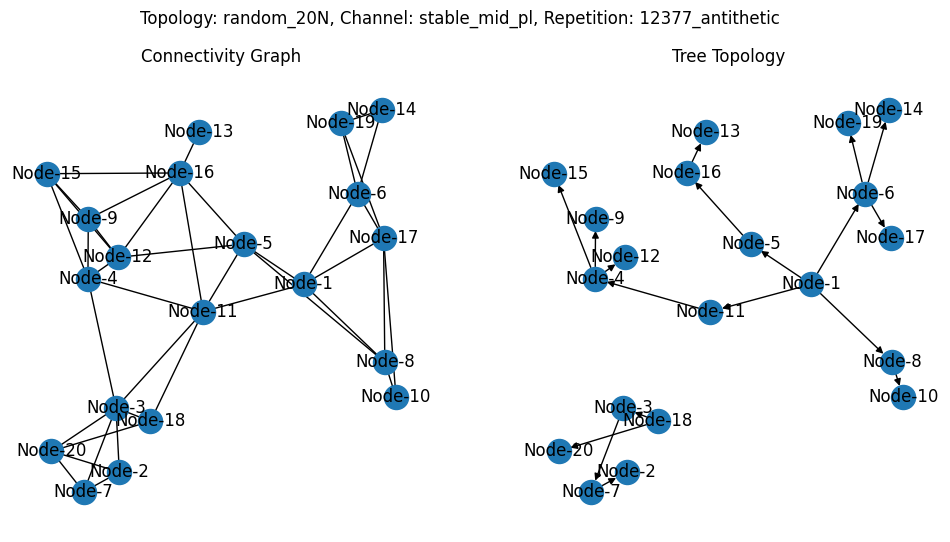

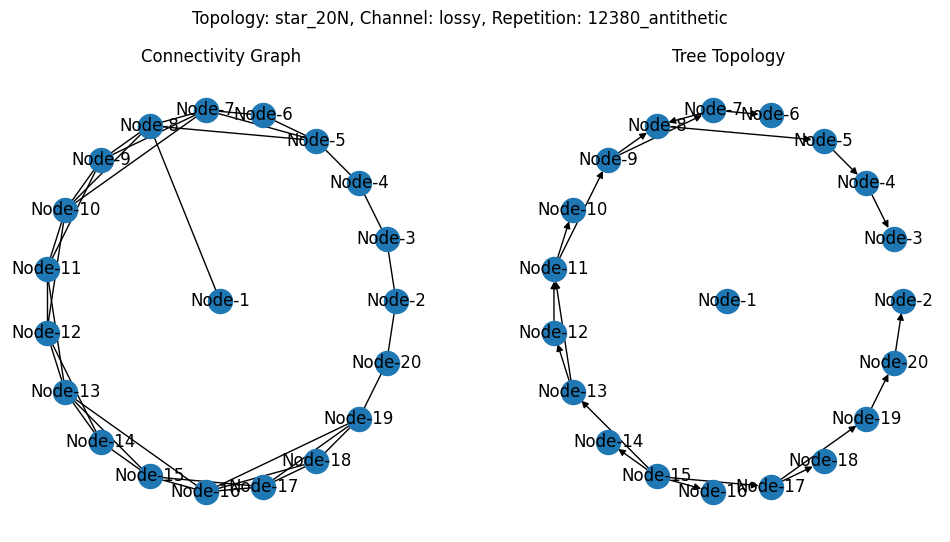

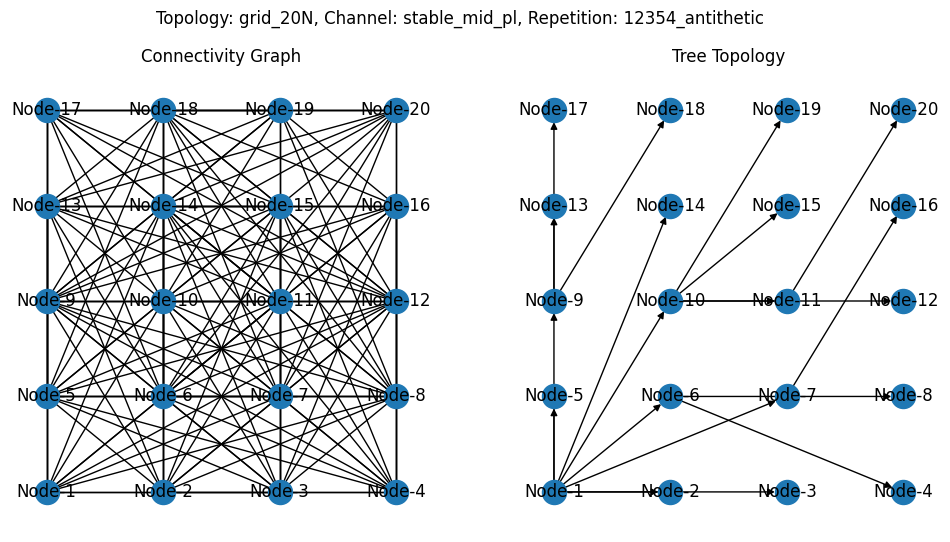

In [ ]:
for topology in results.topologies:
    random_channel = np.random.choice(topology.channels)
    rep = np.random.choice(random_channel.repetitions)

    g = build_connectivity_graph(rep, 200)
    t = build_tree_topology(rep, 200)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))

    nx.draw(g, get_positions_nx(rep), ax=axs[0], with_labels=True)

    nx.draw(t, get_positions_nx(rep), ax=axs[1], with_labels=True)

    plt.suptitle(
        f"Topology: {topology.topology_type}, Channel: {random_channel.channel_type}, Repetition: {rep.id}"
    )
    axs[0].set_title("Connectivity Graph")
    axs[1].set_title("Tree Topology")

    plt.show()

### Plot the Connectivity Graph


Selected channel for grid topology: unstable


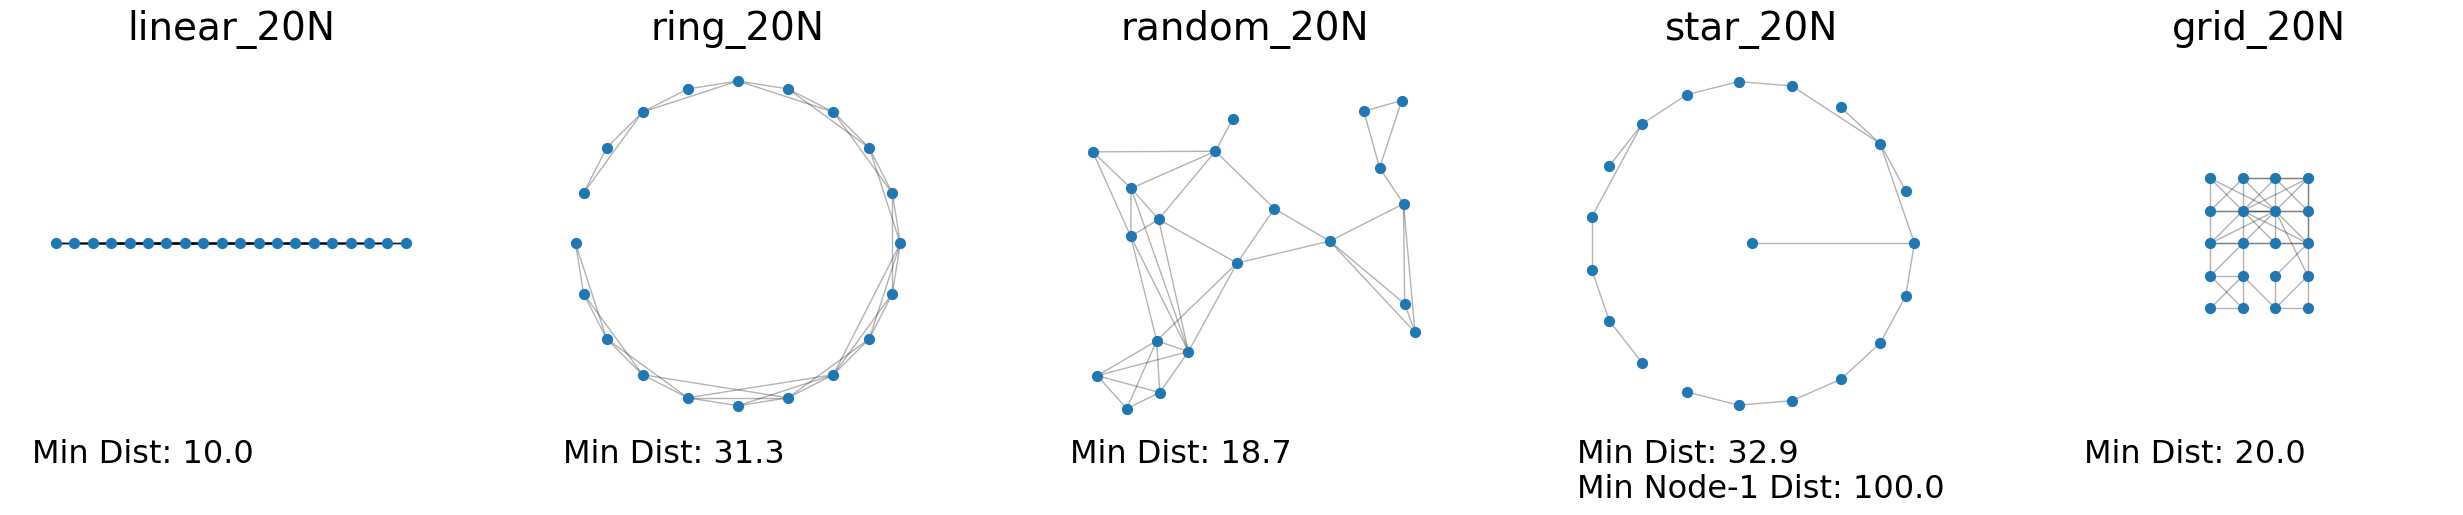

In [166]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

# Create 1 row, 5 columns
fig, axs = plt.subplots(1, 5, figsize=(25, 5))

for i, topology in enumerate(results.topologies[:5]):
    random_channel = np.random.choice(topology.channels)
    random_channel = topology.channels[2]
    if topology.topology_type == "grid_20N":
        random_channel = topology.channels[5]
        print(f"Selected channel for grid topology: {random_channel.channel_type}")
    rep = np.random.choice(random_channel.repetitions)

    # Build connectivity graph only
    g = build_connectivity_graph(rep, 200)

    pos = get_positions_nx(rep)

    # shift positions to center around (0, 0)
    avg_x = np.mean([p[0] for p in pos.values()])
    avg_y = np.mean([p[1] for p in pos.values()])
    pos = {node: (p[0] - avg_x, p[1] - avg_y) for node, p in pos.items()}

    min_dist = min(
        np.linalg.norm(np.array(pos[u]) - np.array(pos[v])) for u in g.nodes() for v in g.neighbors(u) if u != v
    )
    min_node_1_dist = min(
        np.linalg.norm(np.array(pos["Node-1"]) - np.array(node_pos))
        for node_id, node_pos in pos.items()
        if node_id != "Node-1"
    )

    nx.draw_networkx_edges(g, pos, ax=axs[i], alpha=0.3)
    nx.draw_networkx_nodes(g, pos, ax=axs[i], node_size=50)
    # nx.draw_networkx(g, pos, ax=axs[i], with_labels=False, node_size=50, alpha=0.7)

    axs[i].set_title(f"{topology.topology_type}", fontsize=28)
    axs[i].set_axis_off()
    # axs[i].set_axis_on()
    # axs[i].grid(True)
    axs[i].set_xlim(-120, 120)
    axs[i].set_ylim(-120, 120)
    axs[i].set_xticks(np.arange(-120, 121, 30))
    axs[i].set_yticks(np.arange(-120, 121, 30))
    if topology.topology_type != "linear_20N":
        axs[i].set_aspect("equal", adjustable="box")

    axs[i].text(
        0.05,
        0.0,
        (
            f"Min Dist: {min_dist:.1f}"
            + (
                f"\nMin Node-1 Dist: {min_node_1_dist:.1f}"
                if topology.topology_type == "star_20N"
                else ""
            )
        ),
        transform=axs[i].transAxes,
        fontsize=23,
        verticalalignment="top",
    )


# plt.suptitle("Connectivity Graphs of Five Topologies", fontsize=16)
plt.tight_layout()
plt.show()